# Red Neuronal con gradiente desendente no estocastico

El codigo representa una red neuronal "normal" donde se calcula todo el dataset en cada epoca sin hacer particiones del mismo dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [5]:
class CBNN:

    def __init__(self, x_train: list, targets: list, n_iter: int, n_hidden: int, lr: int = 0.1):
        """
        Initializes the neural network with training data and basic parameters.

        Parameters:
        - x_train (list): Input data for training.
        - targets (list): Target values that the neural network should learn to predict.
        - n_iter (int): Number of training iterations.
        - n_hidden (int): Number of neurons in the hidden layer.
        - lr (int): learning rate 

        """
        self.x_train = np.array(x_train)
        self.targets = np.array(targets)
        self.n_iter = n_iter 
        self.hidden_layers = n_hidden
        self.initializeWeightsBias(n_hidden)
        self.lr = lr

    def initializeWeightsBias(self, n_hidden: int) -> None:
        """
        Initializes the weight with method 'He initialization' and bias values for the hidden layer and the output layer

        Parameters:
        - n_hidden (int): Number of neurons in the hidden layer.
        
        """
        input_size = self.x_train.shape[1] # number of features in the input data
        output_size = self.targets.shape[1] # number of output neurons

        # 
        self.ws1 = np.random.randn(n_hidden, input_size) * np.sqrt(2. / input_size)
        
        self.bs1 = np.zeros([1, n_hidden])

        self.ws2 = np.random.randn(output_size, n_hidden) * np.sqrt(2. / n_hidden)
        
        self.bs2 = np.zeros([1, output_size])
        


    def f(self, x: np.ndarray, ws: np.ndarray, bs: np.ndarray) -> np.ndarray:
        """
        Performs the weighted sum of a perceptron(neuron)

        Parameters:
        - x (np.ndarray): Input data
        - ws (np.ndarray): weights values for the neural layer
        - bs (np.ndarray): bias values for the neural layer

        Return:
        - z(np.ndarray): The weighted sum resultating from dot product between of the input data and weights, plus bias
        """
        z = x.dot(ws.T) + bs
        return z

    def relu(self, x):
        act = np.where(x >= 0, x, 0)
        return act

    def gradiente_relu(self, x):
        x_d = np.where(x >= 0, 1, 0)
        return x_d

    def softmax(self, z):
        s=np.sum(np.exp(z), axis=1)
        return (np.exp(z)/s[:,np.newaxis]) #suma de cada fila, se agrega una nueva dimension para que sea un vector columna


    def cross_entropy(self, y, p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.sum(y * np.log(p)) / y.shape[0]
    
    # def initalizer(self):
    
    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Predicts the output for a given input using the trained weights and biases.

        Parameters:
        - x (np.ndarray): Input data for prediction.

        Return:
        - np.ndarray: Predicted output.
        """
        z1 = self.f(x, self.ws1, self.bs1)
        act1 = self.relu(z1)

        z2 = self.f(act1, self.ws2, self.bs2)
        act2 = self.softmax(z2)

        return act2

    def training(self):
        n_samples = self.x_train.shape[0]
        
        for i in range(self.n_iter):
            x_train = self.x_train
            y_train = self.targets
            z1 = self.f(x_train, self.ws1, self.bs1)
            act1 = self.relu(z1)
            z2 = self.f(act1, self.ws2, self.bs2)
            act2 = self.softmax(z2)

            cost = self.cross_entropy(y_train, act2)
            mse = np.mean(cost)

            z_d_2 = act2 - y_train
            w_d_2 = act1.T.dot(z_d_2)
            b_d_2 = np.sum(z_d_2, axis=0, keepdims=True)

            self.ws2 -= self.lr * w_d_2.T / n_samples
            self.bs2 -= self.lr * b_d_2 / n_samples

            cost_l1 = z_d_2.dot(self.ws2) * self.gradiente_relu(z1)
            w_d_1 = cost_l1.T.dot(x_train)
            b_d_1 = np.sum(cost_l1, axis=0, keepdims=True)

            self.ws1 -= self.lr * w_d_1 / n_samples
            self.bs1 -= self.lr * b_d_1 / n_samples
            
            #print(f'Epoch {i} - Loss: {mse:.4f}')

            

LOADING MNIST
Downloading/loading MNIST dataset...
Data loaded: (70000, 784), Targets: (70000, 10)

========== CBNN ==========

Training block: 0 → 25
Accuracy after 25 epochs: 0.6774

Training block: 25 → 50
Accuracy after 50 epochs: 0.7955

Training block: 50 → 75
Accuracy after 75 epochs: 0.8305

Training block: 75 → 100
Accuracy after 100 epochs: 0.8525

Training block: 100 → 125
Accuracy after 125 epochs: 0.8650

Training block: 125 → 150
Accuracy after 150 epochs: 0.8721

Training block: 150 → 175
Accuracy after 175 epochs: 0.8776

Training block: 175 → 200
Accuracy after 200 epochs: 0.8822

Training block: 200 → 225
Accuracy after 225 epochs: 0.8863

Training block: 225 → 250
Accuracy after 250 epochs: 0.8896

Training block: 250 → 275
Accuracy after 275 epochs: 0.8928

Training block: 275 → 300
Accuracy after 300 epochs: 0.8952

Training block: 300 → 325
Accuracy after 325 epochs: 0.8977

Training block: 325 → 350
Accuracy after 350 epochs: 0.8995

Training block: 350 → 375
Acc

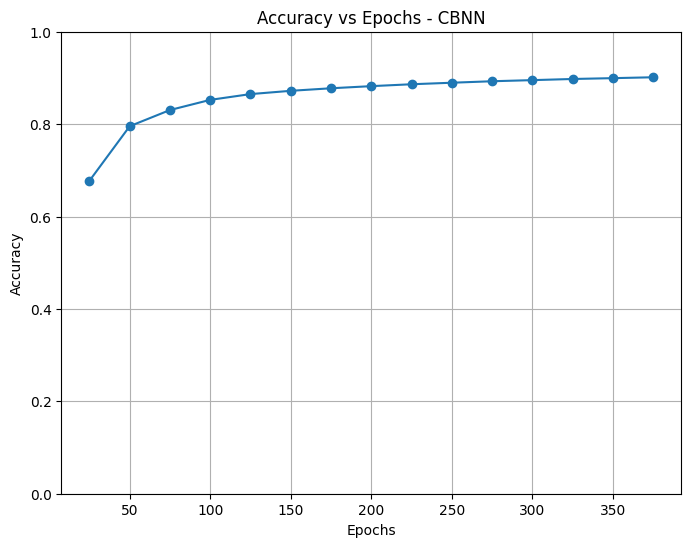

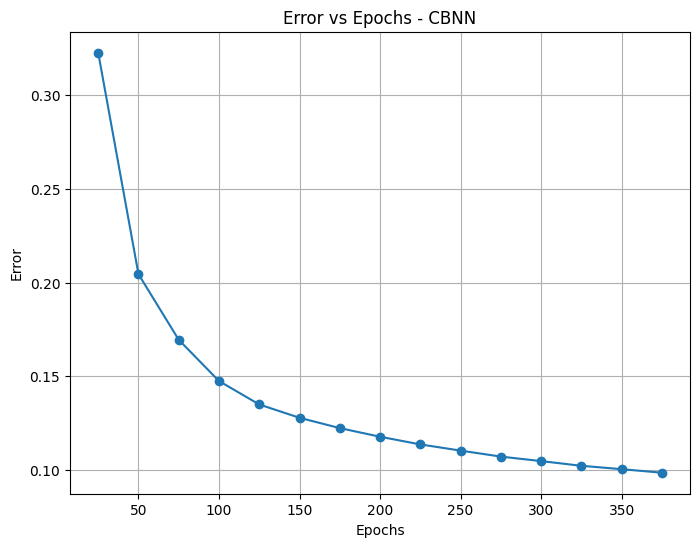

In [6]:
def load_mnist(): 
    print("Downloading/loading MNIST dataset...") 
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser='auto') 
    X = mnist.data.astype(np.float32) / 255.0 
    y = mnist.target.astype(np.int32)
    
    def to_categorical(labels, num_classes=10): 
        one_hot = np.zeros((labels.size, num_classes)) 
        one_hot[np.arange(labels.size), labels] = 1 
        return one_hot 
    
    targets = to_categorical(y, 10)
        
    print(f"Data loaded: {X.shape}, Targets: {targets.shape}") 
    
    return X, targets

def evaluate_accuracy(model, x_test, y_test):

    predictions = model.predict(x_test)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(y_test, axis=1)

    return np.mean(predicted_labels == true_labels)
    
def train_cbbn_progressive(n_epochs=375, n_hidden=50, lr=0.05, n_iter=25):

    print("="*60)
    print("LOADING MNIST")
    print("="*60)

    X, Y = load_mnist()

    n_train = 60000
    n_test = 10000

    x_train = X[:n_train]
    y_train = Y[:n_train]
    x_test = X[n_train:n_train+n_test]
    y_test = Y[n_train:n_train+n_test]

    print("\n========== CBNN ==========")

    model = CBNN(
        x_train=x_train,
        targets=y_train,
        n_iter=n_iter,
        n_hidden=n_hidden,
        lr=lr
    )

    epochs_done = 0
    epoch_points = []
    accuracies = []

    while epochs_done < n_epochs:

        print(f"\nTraining block: {epochs_done} → {epochs_done + n_iter}")

        model.training()

        epochs_done += n_iter

        acc = evaluate_accuracy(model, x_test, y_test)

        epoch_points.append(epochs_done)
        accuracies.append(acc)

        print(f"Accuracy after {epochs_done} epochs: {acc:.4f}")

    # ============================================
    # 🔵 Accuracy vs Epochs
    # ============================================

    plt.figure(figsize=(8,6))
    plt.plot(epoch_points, accuracies, marker='o')
    plt.title("Accuracy vs Epochs - CBNN")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

    # ============================================
    # 🔴 Error vs Epochs
    # ============================================

    errors = [1 - a for a in accuracies]

    plt.figure(figsize=(8,6))
    plt.plot(epoch_points, errors, marker='o')
    plt.title("Error vs Epochs - CBNN")
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":

    train_cbbn_progressive(
        n_epochs=375,
        n_hidden=50,
        lr=0.05,
        n_iter=25
    )

## Comparaciòn entre modelos RN_Arnovi RN_Diego

En esta Comparacion se sacan las graficas de la precision que genera cada uno de los modelos, donde se va comparando en cada 25 epocas la presicion y se grafica estos datos en una solo grafica que compara los dos modelos y su desempeño en base a la presciones obtenidas.

Tambien se grafica como va disminuyendo para cada uno de los modelos

In [14]:
class CBNN:
    def __init__(self, x_train: list, targets: list, n_iter: int, n_hidden: int, lr: float = 0.1, n_batches: int = 5):
        """
        Initializes the neural network with training data and basic parameters.
        
        Parameters:
        - x_train (list): Input data for training.
        - targets (list): Target values (one-hot encoded).
        - n_iter (int): Number of training iterations (epochs).
        - n_hidden (int): Number of neurons in the hidden layer.
        - lr (float): Learning rate.
        - n_batches (int): Number of class-balanced batches to create.
        """
        self.x_train = np.array(x_train)
        self.targets = np.array(targets)
        self.n_iter = n_iter 
        self.hidden_layers = n_hidden
        self.lr = lr
        self.n_batches = n_batches
        self.loss_history = []  # Track loss over epochs
        
        # Store original labels for class-balanced batching (convert one-hot back to indices)
        self.y_labels = np.argmax(self.targets, axis=1)
        
        self.initializeWeightsBias(n_hidden)
        
        # Initialize 5 separate sets of weights and biases for each batch
        self.initializeBatchParameters(n_hidden)

        # Create class-balanced batches once
        self.batch_data, self.batch_targets = self.createClassBalancedBatches()

    def initializeWeightsBias(self, n_hidden: int) -> None:
        """Initialize main weights and biases (used for averaging)."""
        input_size = self.x_train.shape[1]
        output_size = self.targets.shape[1]
        
        # Main parameters (will store the averaged values)
        self.ws1 = np.random.randn(n_hidden, input_size) * np.sqrt(2. / input_size)
        self.bs1 = np.zeros([1, n_hidden])
        self.ws2 = np.random.randn(output_size, n_hidden) * np.sqrt(2. / n_hidden)
        self.bs2 = np.zeros([1, output_size])

    def initializeBatchParameters(self, n_hidden: int) -> None:
        """Initialize separate parameters for each of the 5 batches."""
        input_size = self.x_train.shape[1]
        output_size = self.targets.shape[1]
        
        # Create 5 sets of parameters: ws1_b1, ws1_b2, ..., ws1_b5, etc.
        self.batch_params = []
        
        for i in range(self.n_batches):
            params = {
                'ws1': np.random.randn(n_hidden, input_size) * np.sqrt(2. / input_size),
                'bs1': np.zeros([1, n_hidden]),
                'ws2': np.random.randn(output_size, n_hidden) * np.sqrt(2. / n_hidden),
                'bs2': np.zeros([1, output_size])
            }
            self.batch_params.append(params)
    
    def createClassBalancedBatches(self):
        """
        Creates n_batches class-balanced batches.
        Each batch contains equal number of samples from each class.
        """
        n_classes = self.targets.shape[1]
        samples_per_class_per_batch = self.x_train.shape[0] // (self.n_batches * n_classes)
        
        batch_data = []
        batch_targets = []
        
        # Group indices by class
        class_indices = [np.where(self.y_labels == c)[0] for c in range(n_classes)]
        
        # Shuffle each class's indices
        for indices in class_indices:
            np.random.shuffle(indices)
        
        # Create balanced batches
        for b in range(self.n_batches):
            batch_indices = []
            for c in range(n_classes):
                start_idx = b * samples_per_class_per_batch
                end_idx = (b + 1) * samples_per_class_per_batch
                # Handle case where we might run out of samples
                if end_idx > len(class_indices[c]):
                    end_idx = len(class_indices[c])
                batch_indices.extend(class_indices[c][start_idx:end_idx])
            
            # Shuffle the batch indices
            batch_indices = np.array(batch_indices)
            np.random.shuffle(batch_indices)
            
            batch_data.append(self.x_train[batch_indices])
            batch_targets.append(self.targets[batch_indices])
        
        return batch_data, batch_targets

    def f(self, x: np.ndarray, ws: np.ndarray, bs: np.ndarray) -> np.ndarray:
        """Performs the weighted sum of a perceptron."""
        z = x.dot(ws.T) + bs
        return z

    def relu(self, x):
        return np.where(x >= 0, x, 0)

    def gradiente_relu(self, x):
        return np.where(x >= 0, 1, 0)

    def softmax(self, z):
        z -= np.max(z, axis=1, keepdims=True)
        s = np.sum(np.exp(z), axis=1)
        return np.exp(z) / s[:, np.newaxis]
    
    def cross_entropy(self, y, p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.sum(y * np.log(p)) / y.shape[0]

    def predict(self, x: np.ndarray) -> np.ndarray:
        """Predicts using the averaged (main) parameters."""
        z1 = self.f(x, self.ws1, self.bs1)
        act1 = self.relu(z1)
        z2 = self.f(act1, self.ws2, self.bs2)
        act2 = self.softmax(z2)
        return act2


    def trainBatch(self, x_batch, y_batch, params):
        """Trains on a single batch using specific parameters."""
        total_loss = 0
        m = x_batch.shape[0]
        
        # Create copies to update
        ws1 = params['ws1'].copy()
        bs1 = params['bs1'].copy()
        ws2 = params['ws2'].copy()
        bs2 = params['bs2'].copy()
        
        # Forward pass
        z1 = self.f(x_batch, ws1, bs1)
        act1 = self.relu(z1)
        z2 = self.f(act1, ws2, bs2)
        act2 = self.softmax(z2)
        
        # Loss
        cost = self.cross_entropy(y_batch, act2)
        #cost = self.log_loss(y_batch, act2)
        total_loss += np.sum(cost)
        
        # Backward pass
        z_d_2 = act2 - y_batch
        w_d_2 = act1.T.dot(z_d_2)
        b_d_2 = np.sum(z_d_2, axis=0, keepdims=True)
        
        ws2 -= self.lr * w_d_2.T / m
        bs2 -= self.lr * b_d_2 / m
        
        cost_l1 = z_d_2.dot(ws2) * self.gradiente_relu(z1)
        w_d_1 = cost_l1.T.dot(x_batch)
        b_d_1 = np.sum(cost_l1, axis=0, keepdims=True)
        
        ws1 -= self.lr * w_d_1 / m
        bs1 -= self.lr * b_d_1 / m
    
        # Update params dictionary
        params['ws1'] = ws1
        params['bs1'] = bs1
        params['ws2'] = ws2
        params['bs2'] = bs2
        
        return total_loss

    def averageParameters(self):
        """Averages the parameters from all 5 batches into the main parameters."""
        # Initialize accumulators
        avg_ws1 = np.zeros_like(self.ws1)
        avg_bs1 = np.zeros_like(self.bs1)
        avg_ws2 = np.zeros_like(self.ws2)
        avg_bs2 = np.zeros_like(self.bs2)
        
        # Sum all batch parameters
        for params in self.batch_params:
            avg_ws1 += params['ws1']
            avg_bs1 += params['bs1']
            avg_ws2 += params['ws2']
            avg_bs2 += params['bs2']
        
        # Average
        self.ws1 = avg_ws1 / self.n_batches
        self.bs1 = avg_bs1 / self.n_batches
        self.ws2 = avg_ws2 / self.n_batches
        self.bs2 = avg_bs2 / self.n_batches
        
        # Copy averaged parameters back to each batch for next iteration
        for params in self.batch_params:
            params['ws1'] = self.ws1.copy()
            params['bs1'] = self.bs1.copy()
            params['ws2'] = self.ws2.copy()
            params['bs2'] = self.bs2.copy()

In [15]:
class RN_DIEGO(CBNN):

    def training(self):
        """Training with class-balanced batches and parameter averaging."""
        # Create class-balanced batches once
        batch_data, batch_targets = self.batch_data, self.batch_targets
        
        for epoch in range(self.n_iter):
            epoch_losses = []
            
            # Train each of the 5 batches with their own parameters
            for b in range(self.n_batches):
                loss = self.trainBatch(
                    batch_data[b], 
                    batch_targets[b], 
                    self.batch_params[b]
                )
                epoch_losses.append(loss)
            
            # Average all parameters across the 5 batches
            self.averageParameters()
            
            avg_loss = np.mean(epoch_losses)
            self.loss_history.append(avg_loss)
            #print(f'Epoch {epoch} - Avg Loss: {avg_loss:.4f}')

class RN_ARNOVI(CBNN):
    def training(self):
        """Training with class-balanced batches and parameter averaging."""
        # Create class-balanced batches once
        batch_data, batch_targets = self.batch_data, self.batch_targets
        
        for epoch in range(self.n_iter):
            epoch_losses = []
            
            # Train each of the 5 batches with their own parameters
            for b in range(self.n_batches):
                loss = self.trainBatch(
                    batch_data[b], 
                    batch_targets[b], 
                    self.batch_params[b]
                )
                epoch_losses.append(loss)
            
            
            avg_loss = np.mean(epoch_losses)
            self.loss_history.append(avg_loss)
            #print(f'Epoch {epoch} - Avg Loss: {avg_loss:.4f}')

        self.averageParameters()


LOADING MNIST
Downloading/loading MNIST dataset...
Data loaded: (70000, 784), Targets: (70000, 10)

========== RN_DIEGO ==========

Training block: 0 → 25
Accuracy after 25 epochs: 0.5833

Training block: 25 → 50
Accuracy after 50 epochs: 0.7191

Training block: 50 → 75
Accuracy after 75 epochs: 0.7797

Training block: 75 → 100
Accuracy after 100 epochs: 0.8160

Training block: 100 → 125
Accuracy after 125 epochs: 0.8367

Training block: 125 → 150
Accuracy after 150 epochs: 0.8518

Training block: 150 → 175
Accuracy after 175 epochs: 0.8620

Training block: 175 → 200
Accuracy after 200 epochs: 0.8695

Training block: 200 → 225
Accuracy after 225 epochs: 0.8753

Training block: 225 → 250
Accuracy after 250 epochs: 0.8801

Training block: 250 → 275
Accuracy after 275 epochs: 0.8844

Training block: 275 → 300
Accuracy after 300 epochs: 0.8876

Training block: 300 → 325
Accuracy after 325 epochs: 0.8903

Training block: 325 → 350
Accuracy after 350 epochs: 0.8928

Training block: 350 → 375

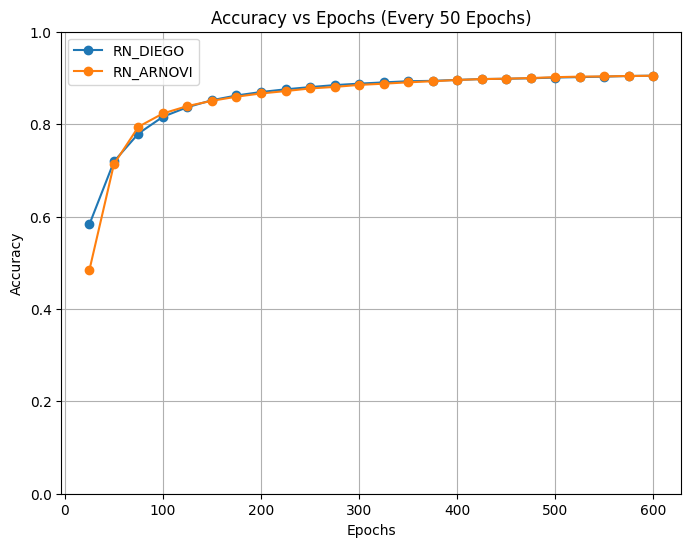

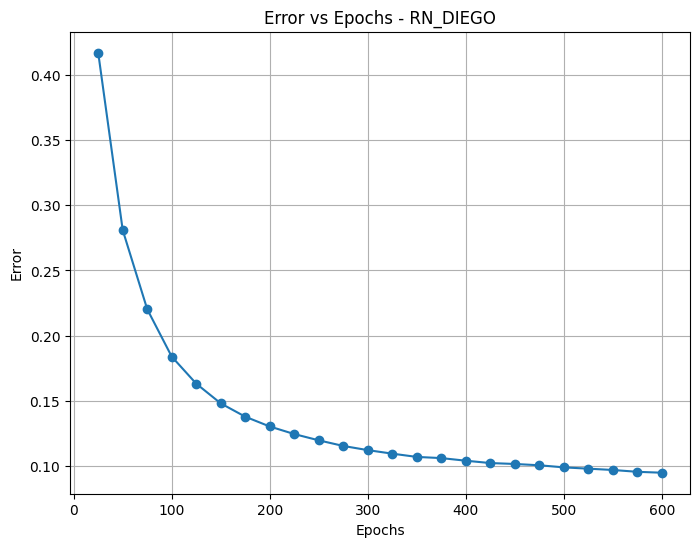

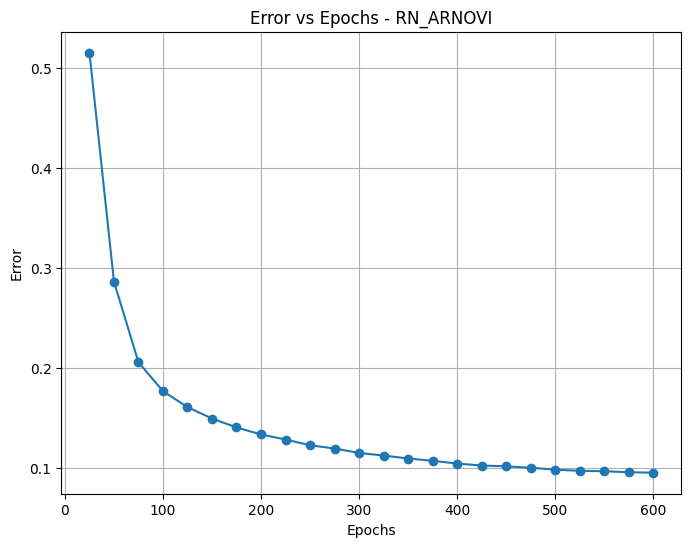

In [16]:
# LOAD MNIST #
def load_mnist(): 
    print("Downloading/loading MNIST dataset...") 
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser='auto') 
    X = mnist.data.astype(np.float32) / 255.0 
    y = mnist.target.astype(np.int32)
    
    def to_categorical(labels, num_classes=10): 
        one_hot = np.zeros((labels.size, num_classes)) 
        one_hot[np.arange(labels.size), labels] = 1 
        return one_hot 
    
    targets = to_categorical(y, 10)
        
    print(f"Data loaded: {X.shape}, Targets: {targets.shape}") 
    
    return X, targets

def evaluate_accuracy(model, x_test, y_test):

    predictions = model.predict(x_test)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(y_test, axis=1)

    return np.mean(predicted_labels == true_labels)

def train_in_blocks(model, x_test, y_test, total_epochs=900, block_size=50):

    epochs_done = 0
    accuracies = []
    epoch_points = []

    while epochs_done < total_epochs:

        print(f"\nTraining block: {epochs_done} → {epochs_done + block_size}")

        model.training()  # ejecuta 50 épocas (definidas en el constructor)

        epochs_done += block_size

        acc = evaluate_accuracy(model, x_test, y_test)

        accuracies.append(acc)
        epoch_points.append(epochs_done)

        print(f"Accuracy after {epochs_done} epochs: {acc:.4f}")

    return epoch_points, accuracies

def compare_models_progressive(n_epochs=300, n_hidden=50, lr=0.05, n_batches=5, n_iter=50):

    print("="*60)
    print("LOADING MNIST")
    print("="*60)

    X, Y = load_mnist()

    n_train = 60000
    n_test = 10000

    x_train = X[:n_train]
    y_train = Y[:n_train]
    x_test = X[n_train:n_train+n_test]
    y_test = Y[n_train:n_train+n_test]

    # ======================================
    # RN_DIEGO
    # ======================================

    print("\n========== RN_DIEGO ==========")

    model_diego = RN_DIEGO(
        x_train=x_train,
        targets=y_train,
        n_iter=n_iter, 
        n_hidden=n_hidden,
        lr=lr,
        n_batches=n_batches
    )

    epochs_diego, acc_diego = train_in_blocks(
        model_diego,
        x_test,
        y_test,
        total_epochs=n_epochs,
        block_size=n_iter
    )

    # ======================================
    # RN_ARNOVI
    # ======================================

    print("\n========== RN_ARNOVI ==========")

    model_arnovi = RN_ARNOVI(
        x_train=x_train,
        targets=y_train,
        n_iter=n_iter, 
        n_hidden=n_hidden,
        lr=lr,
        n_batches=n_batches
    )

    epochs_arnovi, acc_arnovi = train_in_blocks(
        model_arnovi,
        x_test,
        y_test,
        total_epochs=n_epochs,
        block_size=n_iter
    )

    # ============================================
    # 🔵 Precisión superpuesta
    # ============================================

    plt.figure(figsize=(8,6))

    plt.plot(epochs_diego, acc_diego, marker='o', label="RN_DIEGO")
    plt.plot(epochs_arnovi, acc_arnovi, marker='o', label="RN_ARNOVI")

    plt.title("Accuracy vs Epochs (Every 50 Epochs)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.ylim(0,1)
    plt.grid(True)
    plt.legend()
    plt.show()

    # ============================================
    # 🔴 Error RN_DIEGO
    # ============================================

    error_diego = [1 - a for a in acc_diego]

    plt.figure(figsize=(8,6))
    plt.plot(epochs_diego, error_diego, marker='o')
    plt.title("Error vs Epochs - RN_DIEGO")
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.grid(True)
    plt.show()

    # ============================================
    # 🔴 Error RN_ARNOVI
    # ============================================

    error_arnovi = [1 - a for a in acc_arnovi]

    plt.figure(figsize=(8,6))
    plt.plot(epochs_arnovi, error_arnovi, marker='o')
    plt.title("Error vs Epochs - RN_ARNOVI")
    plt.xlabel("Epochs")
    plt.ylabel("Error")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":

    compare_models_progressive(
        n_epochs=600,
        n_hidden=50,
        lr=0.05,
        n_batches=5,
        n_iter=25
    )
    

# Paralelizacion de la Red Neuronal con RN_Diego

En esta ocacion se creo una instancia de una maquina virtual en google cloud, donde se corrio un script con el cual por medio de parametros se le envian al programa la cantidad de procesos a crear, y a usar.

El programa lo que hace es crear una variables globales con las que inicaliza cada procesos creado, donde estas variables son el dataset partido en n batches donde n tambien representa la cantidad de procesos a crear, esto permite que no se tengan que enviar los datos a cada procesos en cada epoca, reduciendo tiempos de ejecucion. El escript, desabilita el uso de hilos ne numpy, lo que permite que no haya una competencia entre los hilos de numpy y los procesos creados por el programa.

# Script usado

``` 
#!/bin/bash

#Primero crear todos los CSV con encabezado
for p in {1..12}
do
    OUTPUT="results_${p}.csv"
    echo "run,time,accuracy" > $OUTPUT
done

echo "Starting experiments..."

#Ahora el loop externo es el número de run
for run in {1..10}
do
    echo "Run $run..."

    # En cada run se recorren todos los procesos
    for p in {1..12}
    do
        OUTPUT="results_${p}.csv"

        echo "   Testing $p processes..."

        result=$(OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 MKL_NUM_THREADS=1 \
                 python RN_Diego_version_2.py --processes $p)

        time=$(echo "$result" | grep -oP 'time=\K[0-9.]+')
        acc=$(echo "$result" | grep -oP 'accuracy=\K[0-9.]+')

        echo "$run,$time,$acc" >> $OUTPUT
    done
done

echo "All experiments completed."
```
